|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Batching<h1>|
|<h2>Section:</h2>|<h1>Static batching<h1>|
|<h2>Lecture:</h2>|<h1><b>Extra users are almost free, until they are not<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

# find the repo root. The directory you start from does not matter.
import sys
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import copy
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

/home/venugopalan/vllm-from-scratch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Extra users are almost free, until they are not

Part 1 ended with a decode step. That step reads every weight to make one
token.

Now read the weights once and make **eight** tokens, for eight different
users. Eight users share one read. The arithmetic grows. The memory traffic
does not.

So one question remains. How far does this continue before something else
breaks?

In [2]:
model = AutoModelForCausalLM.from_pretrained(
          'Qwen/Qwen3-0.6B', dtype=torch.bfloat16).cuda().eval()

weight_bytes = sum(parameter.numel()*parameter.element_size() for parameter in model.parameters())
bandwidth = cudalib.peak_bandwidth(fresh=True)
print(f'weights {weight_bytes/1e9:.2f} GB, bandwidth {bandwidth:.0f} GB/s')

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 15495.15it/s]

weights 1.19 GB, bandwidth 294 GB/s


### Time one decode step, at several batch sizes

`logits_to_keep=1` matters here. Without it, the prefill computes logits for
every position of every sequence. At batch 128 that is ten gigabytes of
numbers that you then discard.

In [3]:
@torch.inference_mode()
def step_ms(batch_size, context_len=256):
  token_ids = torch.randint(0, 1000, (batch_size, context_len), device='cuda')
  cache = model(token_ids, use_cache=True, logits_to_keep=1).past_key_values
  next_token = torch.randint(0, 1000, (batch_size, 1), device='cuda')
  milliseconds = cudalib.bench_ms(
      lambda: model(next_token, past_key_values=copy.copy(cache), use_cache=True),
      iters=10, warmup=3, best_of=2)
  del cache
  torch.cuda.empty_cache()
  return milliseconds

batches = [1,2,4,8,16,32,64,128]
step_times = np.array([step_ms(batch_size) for batch_size in batches])
tokens_per_second = np.array(batches) / (step_times*1e-3)

print(f"{'batch':>6} {'ms/step':>9} {'tok/s':>8} {'ms/token':>9} {'vs B=1':>8}")
for batch_size, step_time, rate in zip(batches, step_times, tokens_per_second):
  print(f'{batch_size:>6} {step_time:>9.2f} {rate:>8.0f} {step_time/batch_size:>9.3f} {rate/tokens_per_second[0]:>7.1f}x')

 batch   ms/step    tok/s  ms/token   vs B=1
     1     11.63       86    11.629     1.0x
     2     11.27      178     5.633     2.1x
     4     11.70      342     2.924     4.0x
     8     11.13      719     1.391     8.4x
    16     12.42     1288     0.776    15.0x
    32     17.48     1831     0.546    21.3x
    64     25.64     2496     0.401    29.0x
   128     51.01     2509     0.399    29.2x


# Two plots of the same table

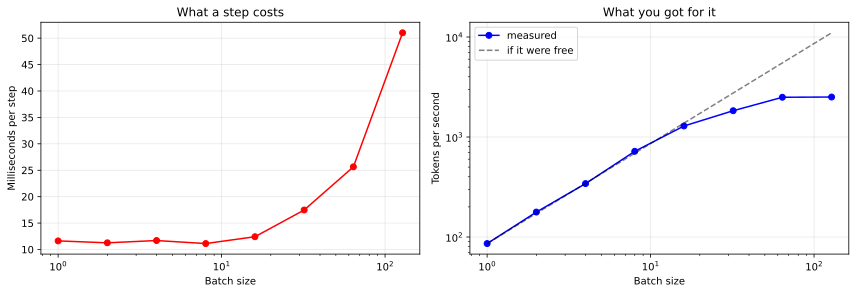

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.2))

axes[0].plot(batches, step_times, 'ro-')
axes[0].set(xscale='log', xlabel='Batch size', ylabel='Milliseconds per step',
           title='What a step costs')
axes[0].grid(alpha=.3)

axes[1].plot(batches, tokens_per_second, 'bo-', label='measured')
axes[1].plot(batches, tokens_per_second[0]*np.array(batches), 'k--', alpha=.5, label='if it were free')
axes[1].set(xscale='log', yscale='log', xlabel='Batch size', ylabel='Tokens per second',
           title='What you got for it')
axes[1].legend()
axes[1].grid(alpha=.3)

plt.tight_layout()
plt.show()

In [5]:
free_batches = [batch_size for batch_size,step_time in zip(batches, step_times) if step_time < 1.25*step_times[0]]
print(f'a step costs the same from batch 1 to batch {max(free_batches)}')
print(f'which is {max(free_batches)}x the tokens for {step_times[batches.index(max(free_batches))]/step_times[0]:.2f}x the time')
print(f'\nbeyond that, throughput still climbs, but you start paying for it')

a step costs the same from batch 1 to batch 16
which is 16x the tokens for 1.07x the time

beyond that, throughput still climbs, but you start paying for it


### This is the ridge point, from the other side

Part 1 computed a ridge in FLOP per byte. It said that the workload ratio is
the batch size. This plot shows the same fact on a clock.

The left half of the plot is the memory-bound region. The weight read controls
the time, and extra sequences travel with it for free.

The flat part ends when the arithmetic becomes the larger term. On this small
model it also ends because the KV cache reads grow with the batch.
PagedAttention exists to push back that second limit.

So raise the batch as far as you can. The next notebook explains why you
cannot.